In [1]:
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = pd.read_csv('../datos_transformados/df_loads_trips.csv', sep=",")

# Variables para el algoritmo
X = df[['actual_distance_miles', 'total_revenue']]

# Limpiamos por si hay nan
X = X.dropna()

# Escalamos para evitar predominancia
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN necesita dos parámetros clave:
# eps (Epsilon): La distancia máxima entre dos puntos para que se consideren vecinos.
# min_samples: El número mínimo de puntos para formar un grupo denso.

# podemos ir probando
dbscan = DBSCAN(eps=0.05, min_samples=100)

# Entrenamiento
clusters = dbscan.fit_predict(X_scaled)

# Añadimos la columna a nuestro df
X['clusters'] = clusters

X['clusters'].value_counts()

clusters
 0    66378
-1     9723
 2     3291
 1     3005
 4     1522
 3     1491
Name: count, dtype: int64

In [2]:
X.columns

Index(['actual_distance_miles', 'total_revenue', 'clusters'], dtype='object')

In [3]:
# Comparar el promedio de distancia y ganancia por grupo
resumen = X.groupby('clusters').agg({
    'actual_distance_miles': 'mean',
    'total_revenue': 'mean',
    'clusters': 'count'
}).rename(columns={'cluster': 'cantidad_viajes'})

print(resumen.round(2))

          actual_distance_miles  total_revenue  clusters
clusters                                                
-1                      2547.01        4688.66      9723
 0                      1317.89        2408.52     66378
 1                        94.23         116.20      3005
 2                      2724.57        5889.08      3291
 3                       171.47         288.00      1491
 4                       269.40         532.10      1522


Aquí tienes la interpretación de tus resultados:

1. Interpretación de los Clusters (Tus Segmentos)
Cluster 0 (El "Core"): Con 66,378 viajes, es tu operación estándar. Son viajes de media distancia (~1,300 millas) con ingresos proporcionales (~$2,400).

Cluster 1 y 3 (Corto Alcance): Viajes muy cortos (94 y 171 millas). El Cluster 1 parece ser de "última milla" con ingresos bajos ($116).

Cluster 2 (Larga Distancia Premium): Estos son tus viajes más rentables. Hacen más de 2,700 millas y generan casi $6,000 de media.

Cluster 4 (Regional): Viajes de unas 270 millas.

2. El problema (y la oportunidad) del Cluster -1
Tienes 9,723 viajes marcados como ruido. Esto es casi un 10% de tu dataset.

En logística, el "ruido" en DBSCAN suele significar:

Viajes ineficientes: Rutas donde se recorrieron muchas millas pero se cobró muy poco.

Errores de captura: Datos que se saltaron la limpieza inicial.

Tarifas especiales: Viajes negociados fuera de los precios estándar.

3. ¿Cómo mejorar esto ahora?
Como el ruido (-1) es bastante alto, tienes dos caminos:

Opción A (Refinar): Si quieres que esos puntos entren en algún grupo, sube el eps un poquito más (de 0.01 a 0.02). Eso "relajará" al algoritmo y absorberá los puntos que están cerca de los grupos.

Opción B (Investigar): Mantén el resultado y analiza solo el Cluster -1. Esos son los viajes que están haciendo perder dinero o que tienen comportamientos extraños.

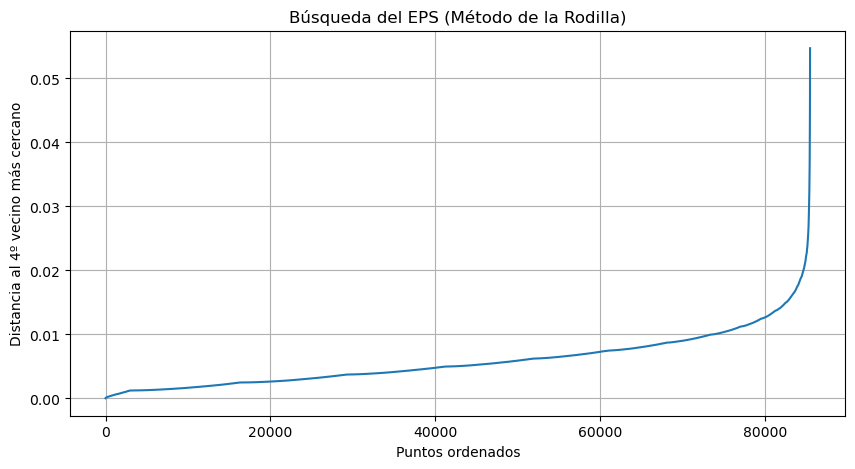

In [4]:
# Elbow method (Método de la rodilla)
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Usamos k = 4 (regla general: 2 * número de dimensiones)
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Ordenamos las distancias
distances = np.sort(distances[:, 3], axis=0)

# Graficamos
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('Búsqueda del EPS (Método de la Rodilla)')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al 4º vecino más cercano')
plt.grid(True)
plt.show()

In [6]:
# Guarda el dataframe con la nueva columna de clusters
df['cluster_dbscan'] = clusters
df.to_csv('./csv_clustering/loads_trips_con_clusters.csv', index=False)

In [7]:
df.columns

Index(['Unnamed: 0', 'customer_id', 'route_id', 'load_date', 'load_type',
       'weight_lbs', 'pieces', 'revenue', 'fuel_surcharge',
       'accessorial_charges', 'booking_type', 'driver_id', 'truck_id',
       'trailer_id', 'dispatch_date', 'actual_distance_miles',
       'actual_duration_hours', 'fuel_gallons_used', 'average_mpg',
       'idle_time_hours', 'total_revenue', 'cluster_dbscan'],
      dtype='object')